## PHASE 3 & 4: BUSINESS VISUALIZATIONS & STRATEGIC INSIGHTS

In [ ]:
# Essential library imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.lines import Line2D

# Suppress technical warnings and file paths in output
import warnings
warnings.filterwarnings('ignore')

# Global environment configuration
pd.set_option("display.max_columns", None)

In [2]:
# Load datasets
df_flights = pd.read_csv("Customer Flight Activity.csv") 
df_loyalty = pd.read_csv("Customer Loyalty History.csv")
df_merged = pd.read_csv("customer_loyalty_cleaned.csv")

In [38]:
df_merged.sample(2)

,loyalty_number,flight_date,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,country,province,city,postal_code,gender,education,salary,is_salary_imputed,marital_status,loyalty_card,clv,enrollment_type,enrollment_date,cancellation_date,is_active,month_num
47788,842279,2017-03,0,0,0,0,0.0,0.0,0.0,Canada,Ontario,Toronto,M2M 7K8,Female,Bachelor,52267.0,False,Married,Nova,9427.68,Standard,2017-12,NaN,True,3
292862,397820,2018-06,5,0,5,1810,181.0,0.0,0.0,Canada,Ontario,Toronto,P1L 8X8,Male,College,73455.0,True,Single,Nova,4574.55,Standard,2016-09,NaN,True,6


### =========================================
### 3. Questions & Visualizations
### =========================================

### 3.1. Q: How is the number of booked flights distributed per month over the year?

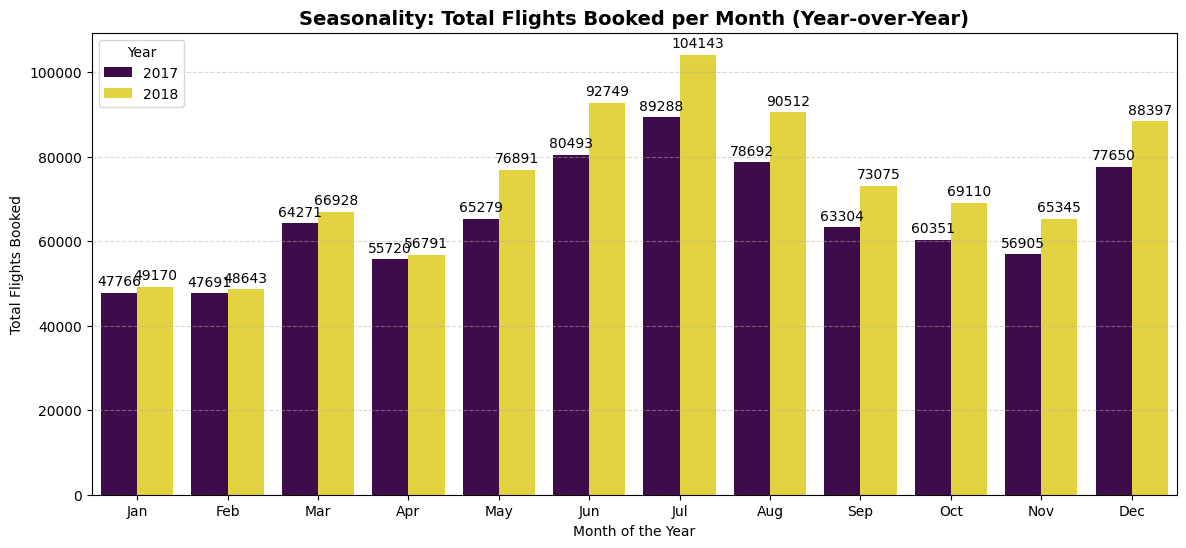

In [ ]:
# Extract the month number from the flight_date Period object
df_merged['month_num'] = pd.to_datetime(df_merged['flight_date'].astype(str)).dt.month
df_merged['year_num'] = pd.to_datetime(df_merged['flight_date'].astype(str)).dt.year

# Group by both year and month to calculate total flights booked
monthly_bookings = df_merged.groupby(['year_num', 'month_num'])['flights_booked'].sum().reset_index()

plt.figure(figsize=(14, 6))
# Using a grouped bar chart to compare years side-by-side
ax = sns.barplot(data=monthly_bookings, x='month_num', y='flights_booked', hue='year_num', palette='viridis')

plt.title("Seasonality: Total Flights Booked per Month (Year-over-Year)", fontsize=14, fontweight='bold')
plt.xlabel("Month of the Year")
plt.ylabel("Total Flights Booked")
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title="Year")

# Add numeric labels to each bar for immediate visual reference
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


**Business Interpretation:**
> *This visualization highlights the seasonality of flight bookings, split by year to provide a true Year-over-Year perspective. By not combining the data, we can clearly see two things: first, the seasonal peaks corresponding to the summer vacation and the end-of-year holidays; and second, the overall increase in flight volume from 2017 to 2018.* 

> *Understanding these temporal trends allows the commercial team to evaluate the loyalty program's ongoing engagement and to optimize seasonal pricing strategies.*

### 3.2. Q2: Is there a relationship between flight distance and accumulated points?

--- Correlation: Distance vs Points Accumulated ---
Overall Spearman Correlation: 0.9981


,loyalty_card,Spearman Correlation
0,Aurora,0.994366
1,Nova,0.998269
2,Star,0.999784


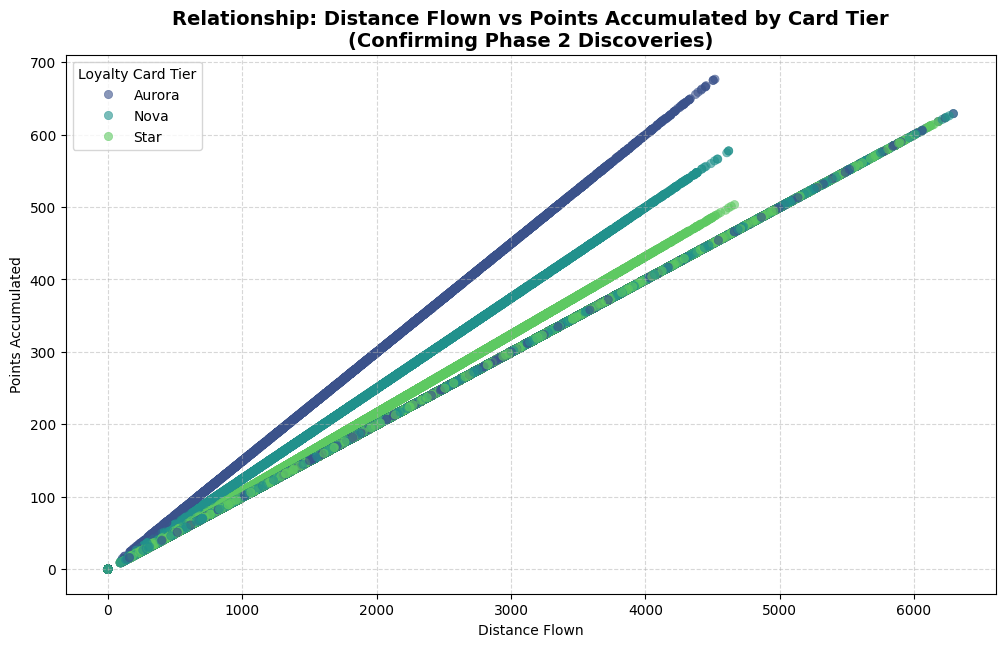

In [41]:
# Calculate Spearman correlation overall and by tier to numerically prove the relationship
print("--- Correlation: Distance vs Points Accumulated ---")
overall_corr = df_merged['distance'].corr(df_merged['points_accumulated'], method='spearman')
print(f"Overall Spearman Correlation: {overall_corr:.4f}")

tier_corr = df_merged.groupby('loyalty_card').apply(
    lambda x: x['distance'].corr(x['points_accumulated'], method='spearman')
).reset_index(name='Spearman Correlation')
display(tier_corr)

plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_merged, x='distance', y='points_accumulated', hue='loyalty_card', 
                palette='viridis', alpha=0.6, edgecolor=None)
plt.title("Relationship: Distance Flown vs Points Accumulated by Card Tier\n(Confirming Phase 2 Discoveries)", fontsize=14, fontweight='bold')
plt.xlabel("Distance Flown")
plt.ylabel("Points Accumulated")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Loyalty Card Tier")
plt.show()

**Business Interpretation:**
> *Yes, there is an absolute, mathematically rigid relationship. As previously explored and discovered in Phase 2, this scatter plot—alongside the correlation table—proves that points are generated strictly based on distance flown (Correlation ~ 0.99). The steeper slope of the 'Aurora' tier clearly demonstrates that premium members accumulate points at a significantly accelerated rate compared to the standard 'Star' tier for the exact same distance.*

### 3.3. Q3: What is the distribution of customers by province or state?

In [ ]:
# Data Preparation for Demographic Questions (Q3 - Q6)
# To answer questions regarding customer profiles (Province, Salary, Education, Gender), we will directly use the 'df_loyalty' dataset. 
# 'df_loyalty' contains one unique record per customer, completely avoiding the duplication issues

df_unique_customers = df_loyalty.copy()
print(f"Demographic Dataset Ready: {df_unique_customers.shape[0]} unique customers isolated from the Loyalty table.")


Demographic Dataset Ready: 16737 unique customers isolated from the Loyalty table.


In [60]:
print(df_unique_customers.columns)

Index(['Loyalty Number', 'Country', 'Province', 'City', 'Postal Code',
       'Gender', 'Education', 'Salary', 'Marital Status', 'Loyalty Card',
       'CLV', 'Enrollment Type', 'Enrollment Year', 'Enrollment Month',
       'Cancellation Year', 'Cancellation Month'],
      dtype='object')


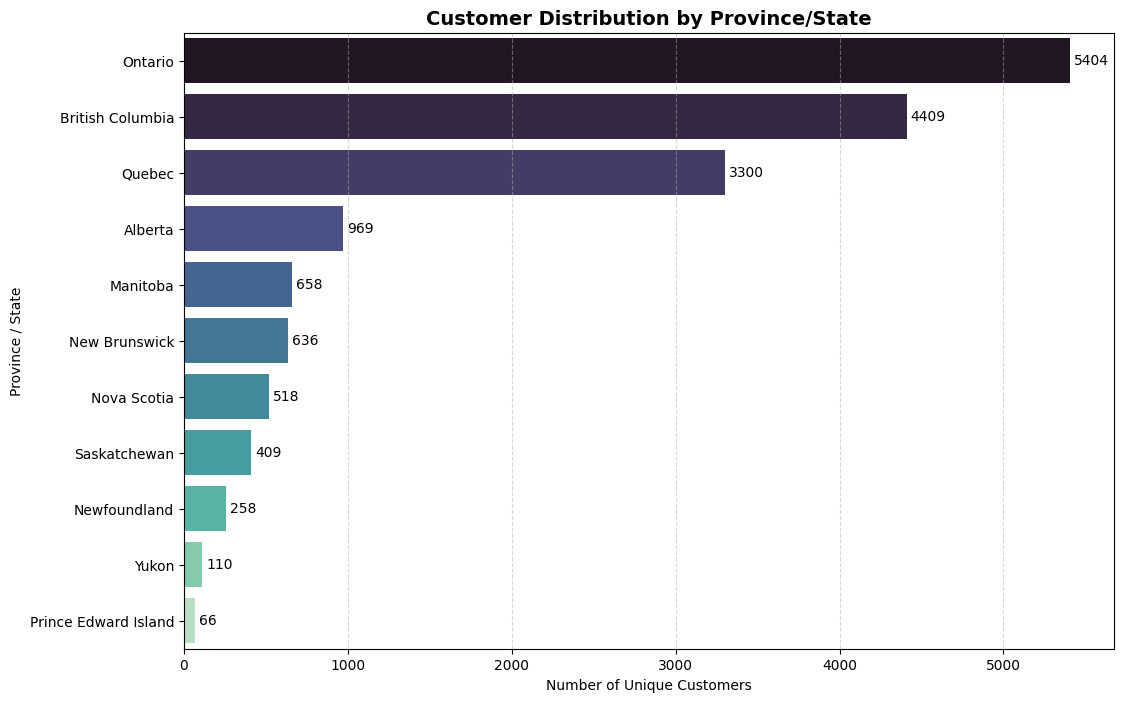

In [ ]:
plt.figure(figsize=(12, 8))

# Ordering the bars by frequency to create a clean Pareto-style distribution
province_order = df_unique_customers['Province'].value_counts().index

ax = sns.countplot(data=df_unique_customers, y='Province', order=province_order, palette='mako')
plt.title("Customer Distribution by Province/State", fontsize=14, fontweight='bold')
plt.xlabel("Number of Unique Customers")
plt.ylabel("Province / State")

# Add numeric labels to each bar for immediate visual reference
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()


**Business Interpretation:**
> *This chart reveals the geographic concentration of the loyalty program. A few key provinces dominate the user base, representing the strongest market penetration. Identifying these strongholds is crucial for regional partnerships (e.g., local car rentals or hotels). Meanwhile, the provinces at the bottom of the chart represent untapped markets where brand awareness campaigns could be deployed to increase market share*

### 3.4. Q4: How does the average salary compare across different education levels?

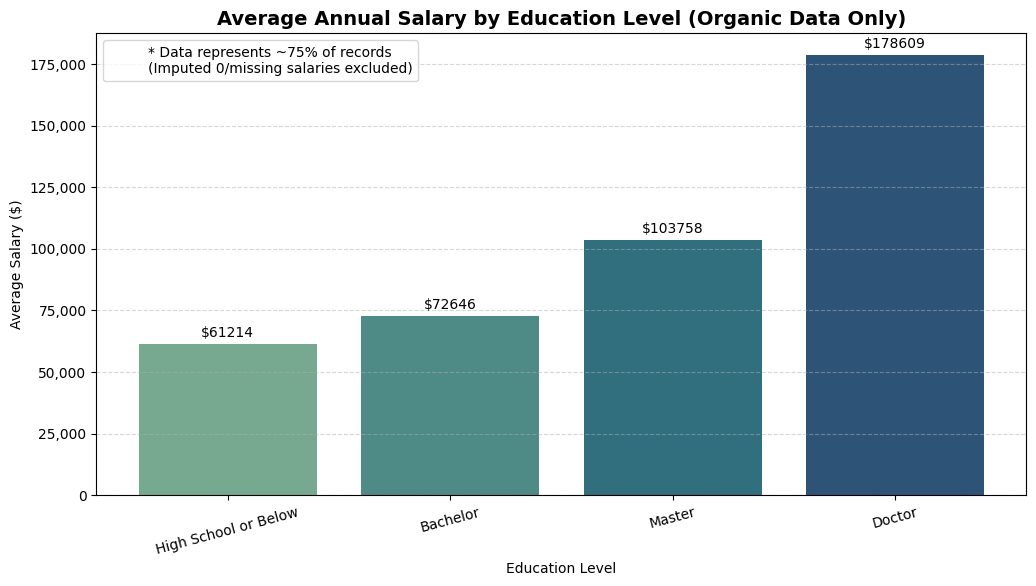

In [ ]:
# Note: We exclude imputed salaries to prevent circular logic. 
# While we initially imputed these values to preserve all records for the main dataset ('df_merged'), 
# keeping them in this specific chart would just reflect our own artificial estimates rather than the true organic data.

plt.figure(figsize=(12, 6))
organic_salary_data = df_merged[df_merged['is_salary_imputed'] == False].drop_duplicates(subset=['loyalty_number'])
# Extracting directly from df_merged to avoid missing column errors, then dropping duplicates for demographic accuracy.

# Setting the specific logical order to show academic progression.
edu_order = ['High School or Below', 'Bachelor', 'Master', 'Doctor']
# Note: 'College' is intentionally excluded because 100% of its original salary data was missing.

# Using barplot with estimator=np.mean to calculate the average salary automatically
ax = sns.barplot(data=organic_salary_data, x='education', y='salary', order=edu_order, estimator=np.mean, 
            palette='crest', capsize=0.1, errorbar=None)

# Add numeric labels to each bar for immediate visual reference 
for container in ax.containers:
    ax.bar_label(container, fmt='$%.0f', padding=3) # formatted as whole dollars

plt.title("Average Annual Salary by Education Level (Organic Data Only)", fontsize=14, fontweight='bold')
plt.xlabel("Education Level")
plt.ylabel("Average Salary ($)")
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}')) # Add commas to salary
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Adding the legend explaining the organic data filter
plt.plot([], [], ' ', label="* Data represents ~75% of records\n(Imputed 0/missing salaries excluded)")
plt.legend(loc='upper left', frameon=True, fontsize=10)

plt.show()


**Business Interpretation:**
> *By analyzing only organically reported data, we observe a clear progression in earning potential correlated with higher education. Advanced degrees (Doctor, Master) command significantly higher average salaries than standard degrees.*

> *Crucial Data Insight (The Missing 'College' Tier):The 'College' demographic is completely absent from this chart. This reveals that 100% of customers with a 'College' education level left their salary blank upon registration. If we had plotted the imputed data, this category would have artificially appeared with the global median salary (~$73,000), leading to a false business conclusion. This absence is a significant behavioral finding—perhaps indicating they are students without a fixed income, or that the sign-up form logic automatically bypassed the salary question for this specific group.*

### 3.5. Q5: What is the proportion of customers with different loyalty card types?

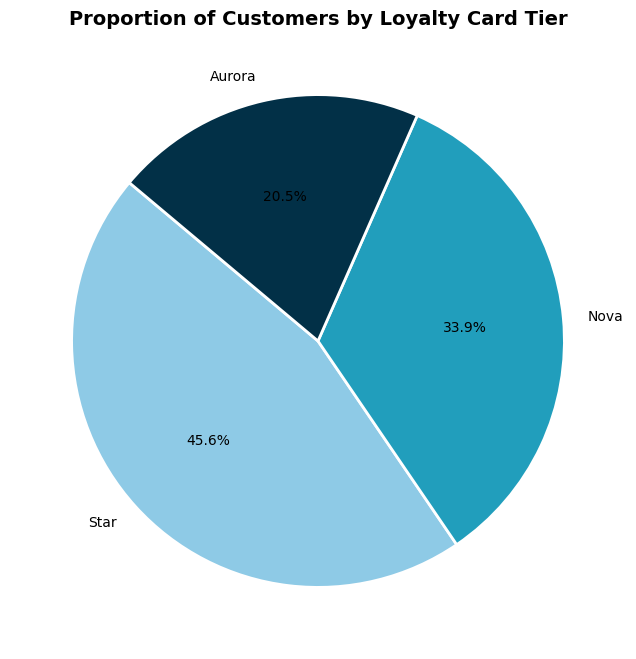

In [64]:
# Calculate raw counts for the pie chart
card_counts = df_unique_customers['Loyalty Card'].value_counts()
colors = ['#8ECAE6', '#219EBC', '#023047'] # Thematic color gradient

plt.figure(figsize=(8, 8))
plt.pie(card_counts, labels=card_counts.index, autopct='%1.1f%%', startangle=140, 
        colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title("Proportion of Customers by Loyalty Card Tier", fontsize=14, fontweight='bold')
plt.show()

**Business Interpretation:**
> *The tier distribution follows a classic pyramid structure. The vast majority of customers sit in the entry-level tier ('Star'), while the highest tier ('Aurora') represents a small, exclusive fraction of the base. This visualization indicates a healthy, aspirational program structure, but it also highlights a massive opportunity: moving even a small percentage of the entry-level base into the middle tier could generate significant revenue.*

### 3.6. Q6: How are customers distributed according to their marital status and gender?

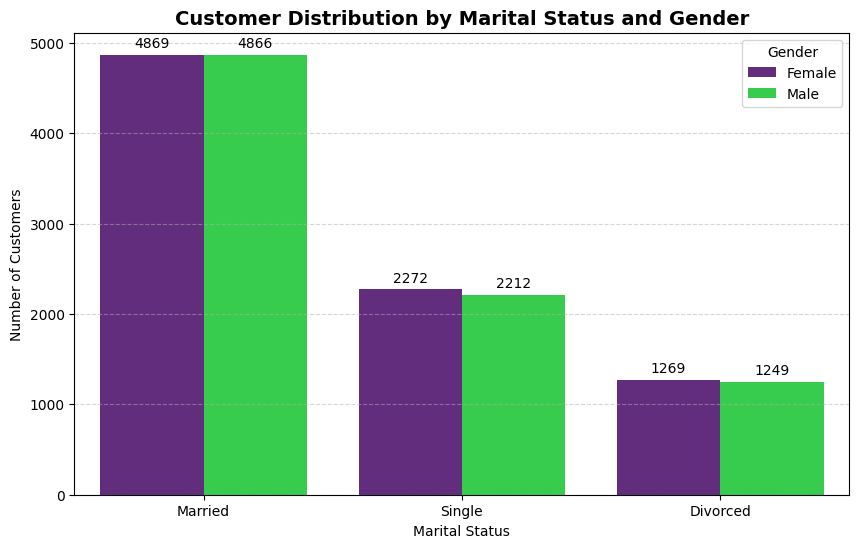

In [ ]:
plt.figure(figsize=(10, 6))

# Ordering the bars by overall frequency
marital_order = df_unique_customers['Marital Status'].value_counts().index
gender_colors = {'Female': "#681F8C", 'Male': "#1EE53C"} 

# Grouped bar chart to compare gender within each marital status
ax = sns.countplot(data=df_unique_customers, x='Marital Status', hue='Gender', order=marital_order, palette=gender_colors)

plt.title("Customer Distribution by Marital Status and Gender", fontsize=14, fontweight='bold')
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")
plt.legend(title='Gender')

# Add numeric labels to each bar for immediate visual reference
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**Business Interpretation:**
> *The demographic is remarkably balanced across genders within every single marital status category. The dominant segment consists of married individuals. This insight strongly suggests that marketing campaigns should be gender-neutral and focused on "plus-one" or family-oriented travel benefits, as the majority of the user base is statistically likely to travel with a partner.*

### =========================================
### 4. Evaluating differences in flights bookings by education level
### =========================================

In [89]:
# Filter the dataset for the relevant columns
df_education_flights = df_merged[['education', 'flights_booked']].copy()

print("--- Data Preparation Complete ---")
print(f"Dataset extracted with {df_education_flights.shape[0]} records.")
display(df_education_flights.sample(5))


--- Data Preparation Complete ---
Dataset extracted with 405624 records.


,education,flights_booked
151232,Bachelor,10
123980,Bachelor,2
199060,Doctor,0
243103,Bachelor,11
54538,Bachelor,0


In [93]:
# Group by education and calculate descriptive statistics
education_flight_stats = df_education_flights.groupby('education')['flights_booked'].agg(
    ['count', 'mean', 'std', 'min', 'max']
).reset_index()

# Rename columns for presentation and readability
education_flight_stats.columns = ['Education Level', 'Total Records (Months)', 'Avg Flights Booked', 'Standard Deviation', 'Min Booked', 'Max Booked']

# Sort the table logically by the average number of flights booked (descending)
education_flight_stats = education_flight_stats.sort_values(by='Avg Flights Booked', ascending=False)

print("\n--- Descriptive Statistics: Flights Booked by Education Level ---")
display(education_flight_stats.round(2))



--- Descriptive Statistics: Flights Booked by Education Level ---


,Education Level,Total Records (Months),Avg Flights Booked,Standard Deviation,Min Booked,Max Booked
4,Master,12336,4.18,5.21,0,21
3,High School or Below,19008,4.16,5.23,0,21
1,College,102672,4.15,5.24,0,21
2,Doctor,17856,4.15,5.25,0,21
0,Bachelor,253752,4.09,5.22,0,21


**Business Interpretation:**

This descriptive table provides a preliminary look into booking behaviors across different educational segments. By observing the 'Avg Flights Booked', we can see that the averages are extremely close to each other (ranging only from ~4.09 to ~4.18).

> *Crucial Data Insight (The "21 Flights" Ceiling):You might notice that the 'Max Booked' is exactly 21 across all education levels. This is not a calculation error. While our dataset spans a full 24 months (2017-2018), each individual row represents a customer's activity for one specific month. Finding a maximum of 21 means that in every single educational group, there was at least one "super-flyer" who hit an absolute ceiling of 21 flights in a single month. This suggests either a natural human limit to how much one can fly in 30 days, or a hard system cap on monthly bookings, consistently present across all demographics.*

> **Final Conclusion:** *Based purely on the descriptive statistics, the absolute difference of ~0.09 flights per month between a Master's degree (the highest) and a Bachelor's degree (the lowest) is completely negligible for any marketing strategy. Therefore, we can safely conclude that while education strongly dictates **salary** (as proven in Phase 3), it is practically irrelevant for driving **flight frequency**.*